#### AULA 3
##### Subplot e layouts


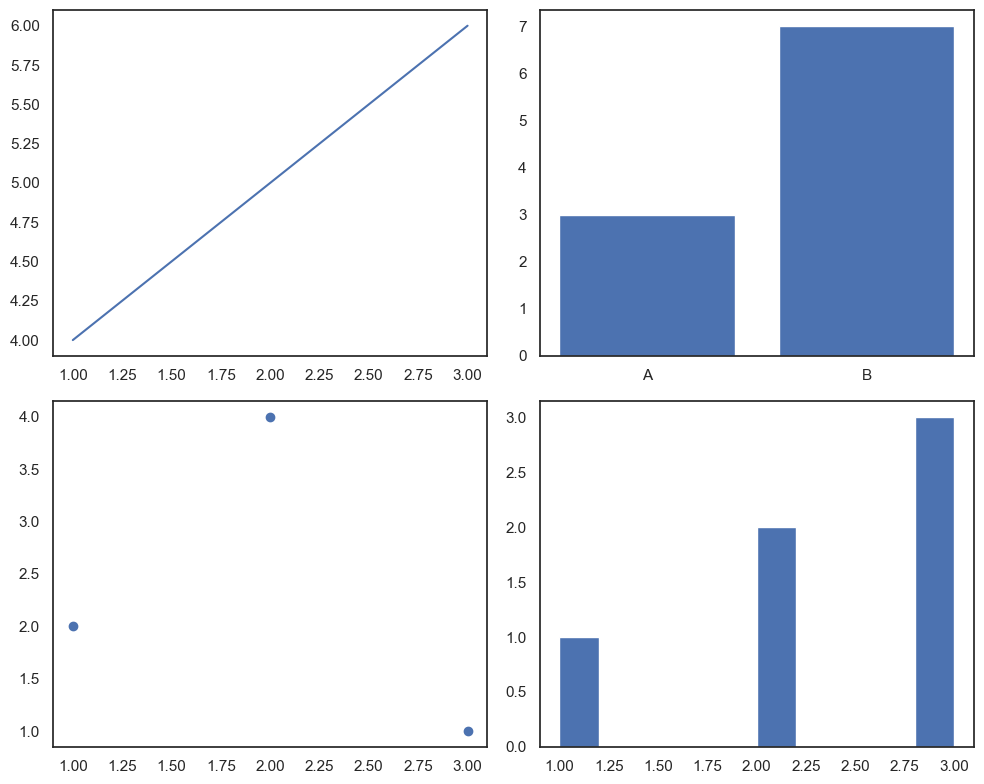

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
# Cria uma grade 2x2 de subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Acessa cada eixo individualmente
axes[0, 0].plot([1, 2, 3], [4, 5, 6])
axes[0, 1].bar(['A', 'B'], [3, 7])
axes[1, 0].scatter([1, 2, 3], [2, 4, 1])
axes[1, 1].hist([1, 2, 2, 3, 3, 3])

plt.tight_layout()
plt.show()


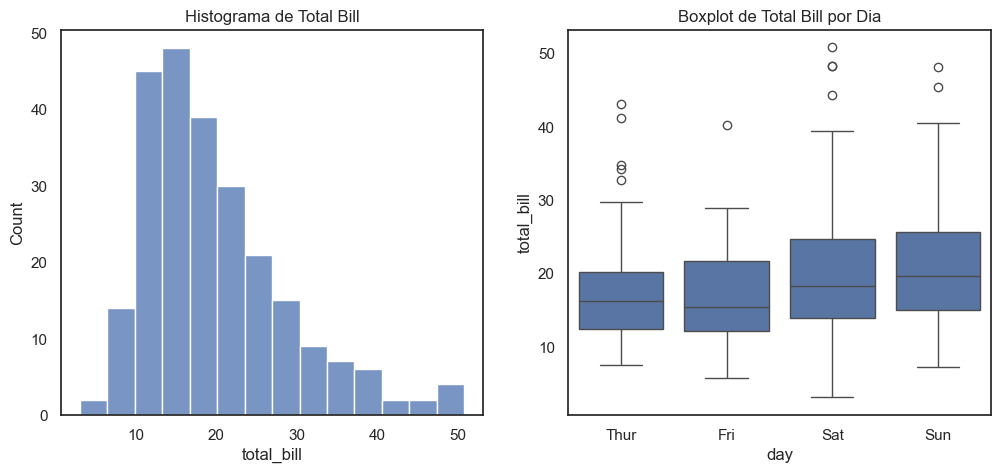

In [28]:
import seaborn as sns

# Carrega dataset de exemplo
tips = sns.load_dataset("tips")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma no primeiro eixo
sns.histplot(data=tips, x="total_bill", ax=axes[0])

# Boxplot no segundo eixo
sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[1])

axes[0].set_title("Histograma de Total Bill")
axes[1].set_title("Boxplot de Total Bill por Dia")

plt.savefig(
    "grafico.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()





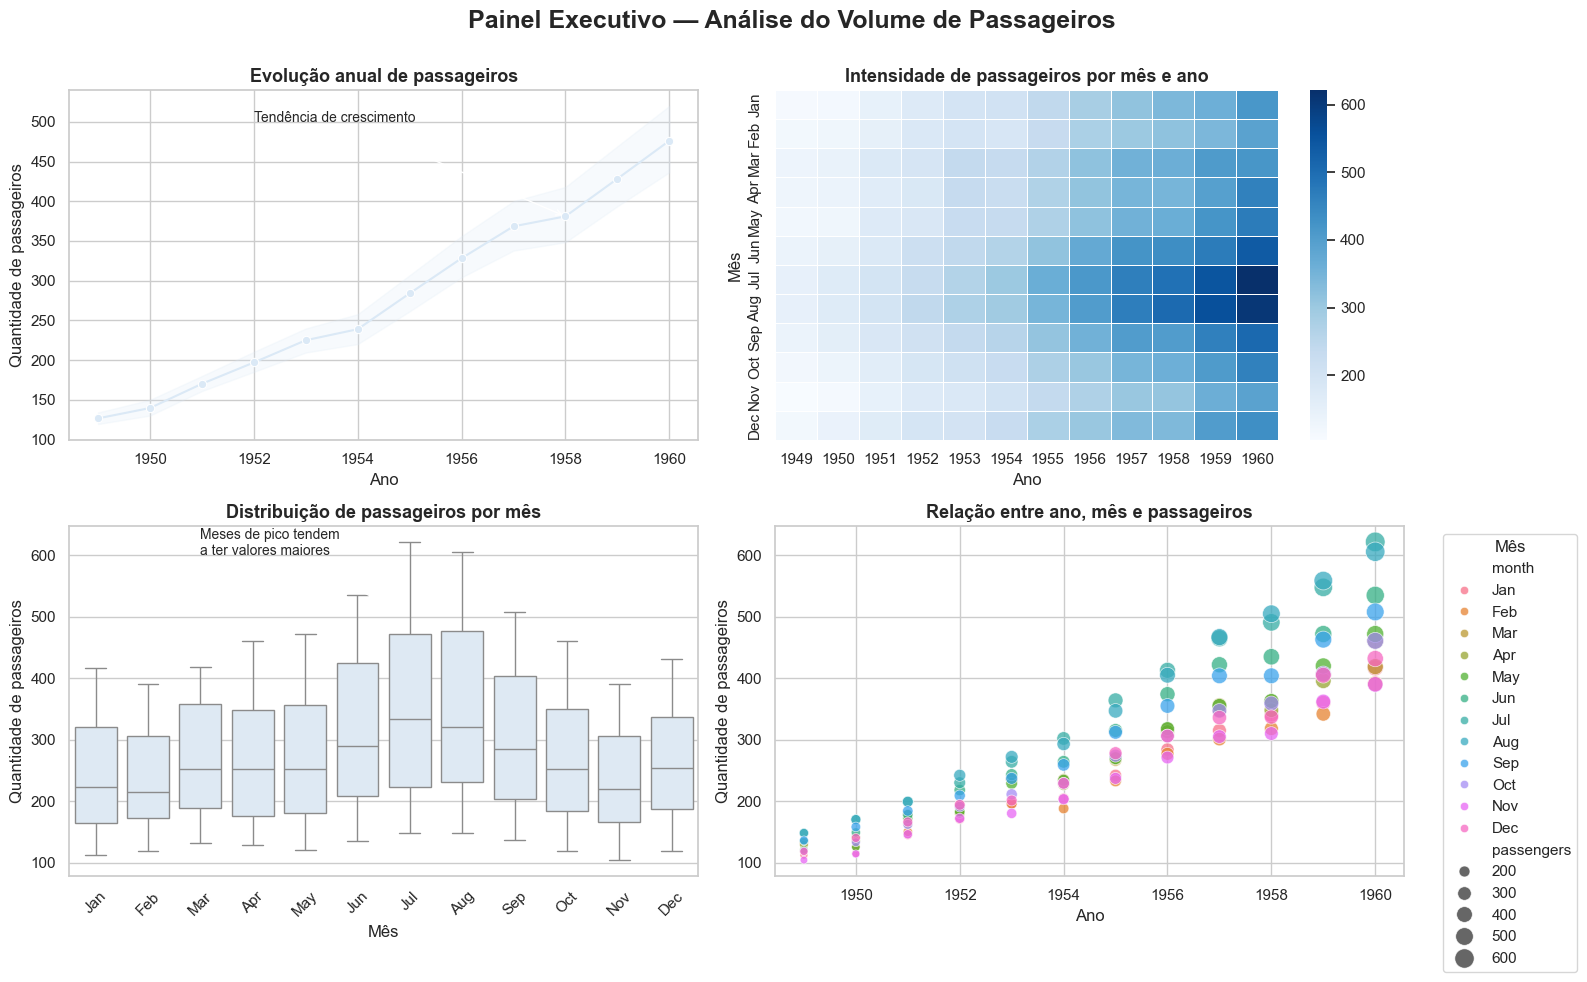

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar dataset
flights = sns.load_dataset("flights")

# Tema, paleta e contexto
sns.set_theme(
    style="whitegrid",
    palette="Blues",
    context="notebook"
)

# Criar painel 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -----------------------------
# 1. Linha temporal
# -----------------------------
sns.lineplot(
    data=flights,
    x="year",
    y="passengers",
    marker="o",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Evolução anual de passageiros", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("Ano")
axes[0, 0].set_ylabel("Quantidade de passageiros")

axes[0, 0].annotate(
    "Tendência de crescimento",
    xy=(1958, flights[flights["year"] == 1958]["passengers"].mean()),
    xytext=(1952, 500),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)
# Criar base para o heatmap
flights_pivot = flights.pivot(
    index="month",
    columns="year",
    values="passengers"
)
# -----------------------------
# 2. Heatmap
# -----------------------------
sns.heatmap(
    flights_pivot,
    cmap="Blues",
    annot=False,
    linewidths=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Intensidade de passageiros por mês e ano", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("Ano")
axes[0, 1].set_ylabel("Mês")

# -----------------------------
# 3. Boxplot
# -----------------------------
sns.boxplot(
    data=flights,
    x="month",
    y="passengers",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribuição de passageiros por mês", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Mês")
axes[1, 0].set_ylabel("Quantidade de passageiros")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 0].annotate(
    "Meses de pico tendem\na ter valores maiores",
    xy=(6, 500),
    xytext=(2, 600),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# -----------------------------
# 4. Scatterplot
# -----------------------------
sns.scatterplot(
    data=flights,
    x="year",
    y="passengers",
    hue="month",
    size="passengers",
    sizes=(30, 200),
    alpha=0.75,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Relação entre ano, mês e passageiros", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Ano")
axes[1, 1].set_ylabel("Quantidade de passageiros")

# Ajustar legenda
axes[1, 1].legend(
    title="Mês",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Título geral
fig.suptitle(
    "Painel Executivo — Análise do Volume de Passageiros",
    fontsize=18,
    weight="bold"
)

# Ajustar espaçamento
plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

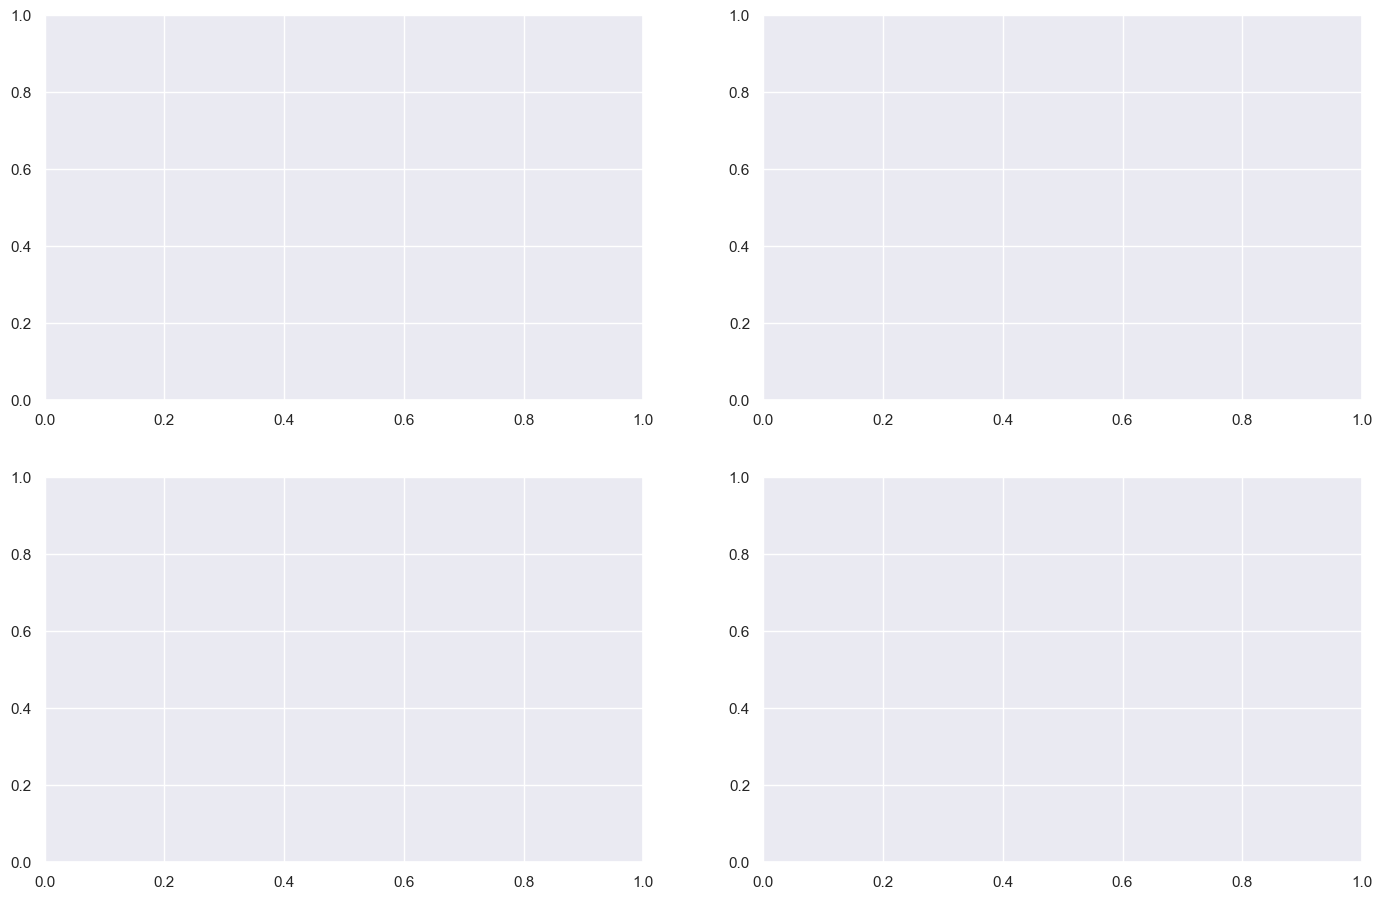

In [18]:
# Criar painel 2x2
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

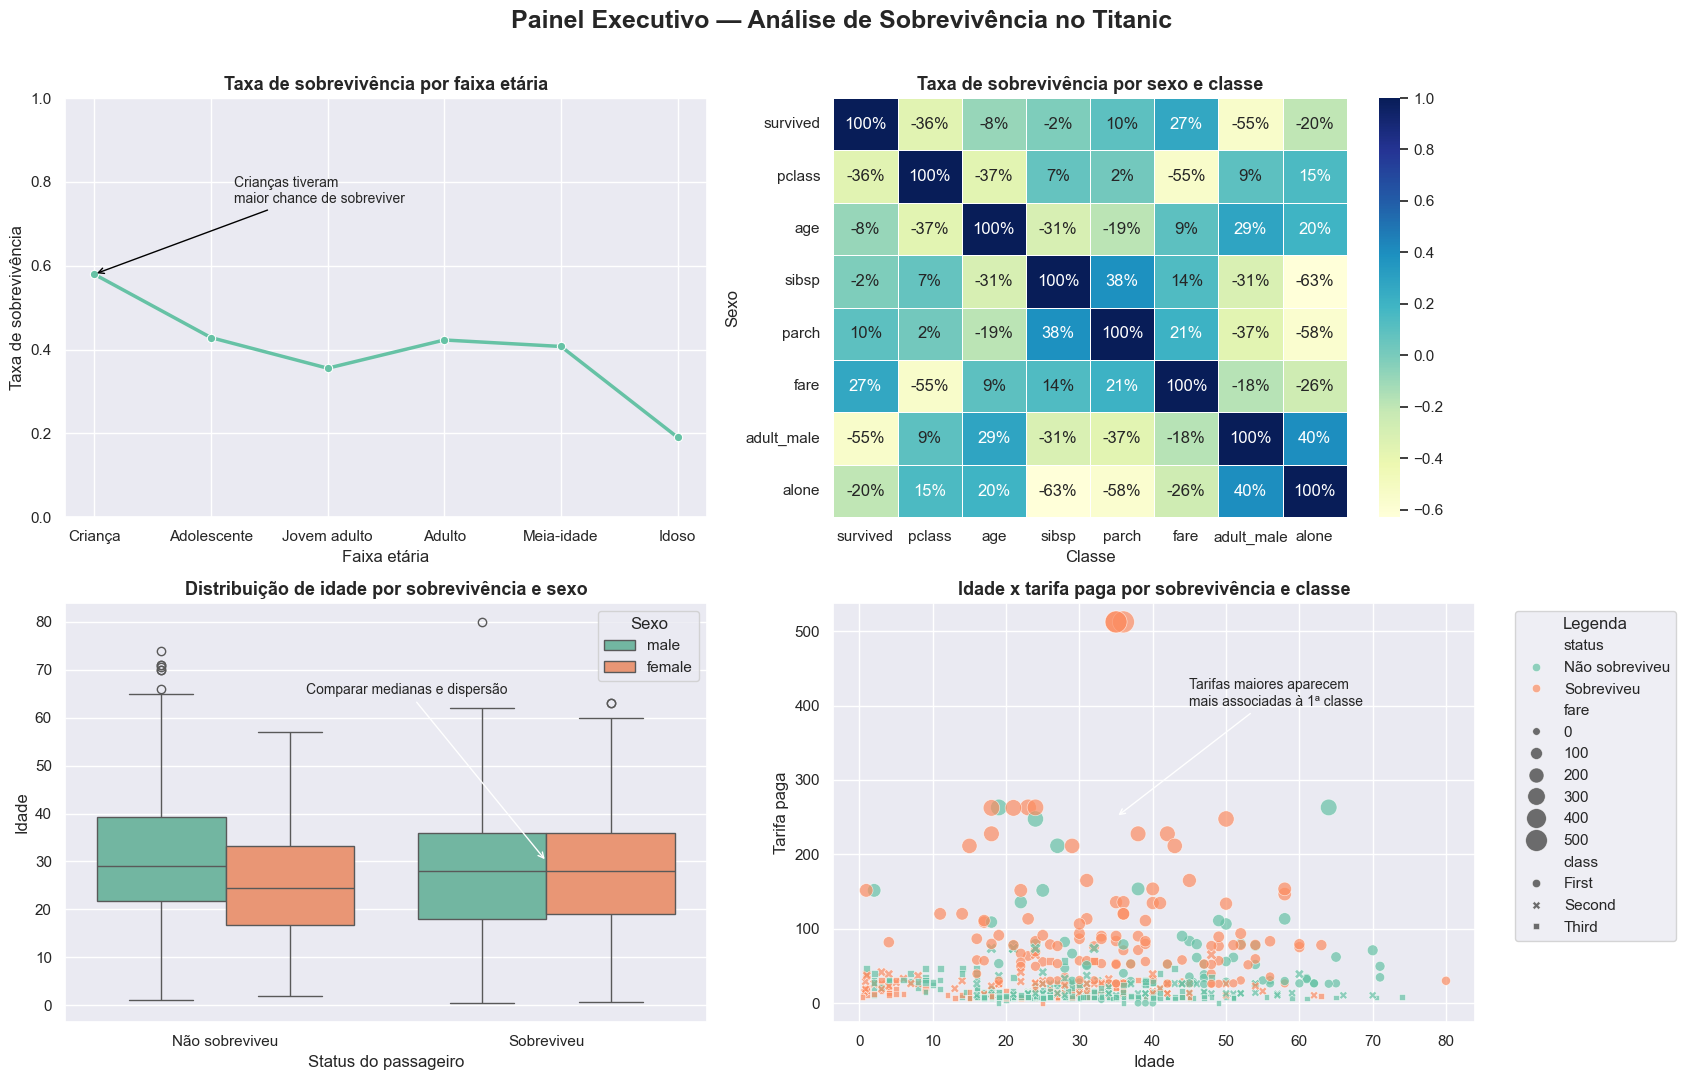

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Carregar o dataset Titanic
titanic = sns.load_dataset("titanic")

# Remover registros sem idade e sem tarifa para evitar problemas nos gráficos
df = titanic.dropna(subset=["age", "fare", "sex", "class", "survived", "embark_town"]).copy()

# Criar uma coluna mais interpretável para sobrevivência
df["status"] = df["survived"].map({
    0: "Não sobreviveu",
    1: "Sobreviveu"
})

# Agrupar idade em faixas para o gráfico de linha
df["faixa_idade"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 30, 45, 60, 80],
    labels=["Criança", "Adolescente", "Jovem adulto", "Adulto", "Meia-idade", "Idoso"]
)

# Tema geral
sns.set_theme(
    style="darkgrid",
    palette="Set2"
)

# Criar painel 2x2
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# --------------------------------------------------
# 1. Linha temporal / ordenada: sobrevivência por faixa etária
# --------------------------------------------------
sobrevivencia_idade = (
    df.groupby("faixa_idade", observed=True)["survived"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=sobrevivencia_idade,
    x="faixa_idade",
    y="survived",
    marker="o",
    linewidth=2.5,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Taxa de sobrevivência por faixa etária", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("Faixa etária")
axes[0, 0].set_ylabel("Taxa de sobrevivência")
axes[0, 0].set_ylim(0, 1)

axes[0, 0].annotate(
    "Crianças tiveram\nmaior chance de sobreviver",
    xy=(0, sobrevivencia_idade.loc[0, "survived"]),
    xytext=(1.2, 0.75),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

# --------------------------------------------------
# 2. Heatmap: sobrevivência por sexo e classe
# --------------------------------------------------

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Taxa de sobrevivência por sexo e classe", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("Classe")
axes[0, 1].set_ylabel("Sexo")

# --------------------------------------------------
# 3. Boxplot: idade por sobrevivência e sexo
# --------------------------------------------------
sns.boxplot(
    data=df,
    x="status",
    y="age",
    hue="sex",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribuição de idade por sobrevivência e sexo", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Status do passageiro")
axes[1, 0].set_ylabel("Idade")
axes[1, 0].legend(title="Sexo")

axes[1, 0].annotate(
    "Comparar medianas e dispersão",
    xy=(1, 30),
    xytext=(0.25, 65),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# --------------------------------------------------
# 4. Scatterplot: idade x tarifa, relacionando classe e sobrevivência
# --------------------------------------------------
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="status",
    style="class",
    size="fare",
    sizes=(30, 250),
    alpha=0.7,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Idade x tarifa paga por sobrevivência e classe", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Idade")
axes[1, 1].set_ylabel("Tarifa paga")

axes[1, 1].annotate(
    "Tarifas maiores aparecem\nmais associadas à 1ª classe",
    xy=(35, 250),
    xytext=(45, 400),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

axes[1, 1].legend(
    title="Legenda",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Título geral
fig.suptitle(
    "Painel Executivo — Análise de Sobrevivência no Titanic",
    fontsize=18,
    weight="bold"
)

# Ajuste de espaçamento
plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --------------------------------------------------
# Carregar e preparar os dados
# --------------------------------------------------
titanic = sns.load_dataset("titanic")

df = titanic.dropna(
    subset=["age", "fare", "sex", "class", "survived", "embark_town"]
).copy()

df["status"] = df["survived"].map({
    0: "Não sobreviveu",
    1: "Sobreviveu"
})

df["sexo"] = df["sex"].map({
    "male": "Masculino",
    "female": "Feminino"
})

df["classe"] = df["class"].astype(str)

df["faixa_idade"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 30, 45, 60, 80],
    labels=[
        "Criança",
        "Adolescente",
        "Jovem adulto",
        "Adulto",
        "Meia-idade",
        "Idoso"
    ]
)

# --------------------------------------------------
# Dados para o gráfico de linha
# --------------------------------------------------
sobrevivencia_idade = (
    df.groupby("faixa_idade", observed=True)["survived"]
    .mean()
    .reset_index()
)

# --------------------------------------------------
# Dados para o heatmap
# --------------------------------------------------
heatmap_data = df.pivot_table(
    values="survived",
    index="sexo",
    columns="classe",
    aggfunc="mean",
    observed=True
)

# --------------------------------------------------
# Criar painel 2x2
# --------------------------------------------------
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Taxa de sobrevivência por faixa etária",
        "Taxa de sobrevivência por sexo e classe",
        "Distribuição de idade por sobrevivência e sexo",
        "Idade x tarifa paga por sobrevivência e classe"
    ],
    specs=[
        [{"type": "scatter"}, {"type": "heatmap"}],
        [{"type": "box"}, {"type": "scatter"}]
    ],
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

# --------------------------------------------------
# 1. Gráfico de linha
# --------------------------------------------------
fig.add_trace(
    go.Scatter(
        x=sobrevivencia_idade["faixa_idade"],
        y=sobrevivencia_idade["survived"],
        mode="lines+markers",
        name="Sobrevivência por idade",
        line=dict(width=3),
        marker=dict(size=9),
        hovertemplate=(
            "Faixa etária: %{x}<br>"
            "Taxa de sobrevivência: %{y:.1%}<extra></extra>"
        )
    ),
    row=1,
    col=1
)

fig.add_annotation(
    x="Criança",
    y=sobrevivencia_idade.loc[
        sobrevivencia_idade["faixa_idade"] == "Criança",
        "survived"
    ].values[0],
    text="Crianças tiveram maior taxa",
    showarrow=True,
    arrowhead=2,
    row=1,
    col=1
)

# --------------------------------------------------
# 2. Heatmap
# --------------------------------------------------
fig.add_trace(
    go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index,
        colorscale="Blues",
        text=heatmap_data.applymap(lambda x: f"{x:.0%}").values,
        texttemplate="%{text}",
        hovertemplate=(
            "Sexo: %{y}<br>"
            "Classe: %{x}<br>"
            "Taxa de sobrevivência: %{z:.1%}<extra></extra>"
        ),
        colorbar=dict(
            title="Taxa de<br>sobrevivência",
            x=1.02,      # posição horizontal da barra
            y=0.79,      # sobe a barra para alinhar melhor com o heatmap
            len=0.42,    # altura da barra
            thickness=18
        ),
        showscale=True
    ),
    row=1,
    col=2
)
# --------------------------------------------------
# 3. Boxplot
# --------------------------------------------------
for sexo in df["sexo"].unique():
    dados_sexo = df[df["sexo"] == sexo]

    fig.add_trace(
        go.Box(
            x=dados_sexo["status"],
            y=dados_sexo["age"],
            name=f"Idade - {sexo}",
            boxmean=True,
            hovertemplate=(
                "Status: %{x}<br>"
                "Idade: %{y}<extra></extra>"
            )
        ),
        row=2,
        col=1
    )

fig.add_annotation(
    x="Sobreviveu",
    y=65,
    text="Compare mediana e dispersão",
    showarrow=True,
    arrowhead=2,
    row=2,
    col=1
)

# --------------------------------------------------
# 4. Scatterplot
# --------------------------------------------------
for status in df["status"].unique():
    dados_status = df[df["status"] == status]

    fig.add_trace(
        go.Scatter(
            x=dados_status["age"],
            y=dados_status["fare"],
            mode="markers",
            name=status,
            marker=dict(
                size=dados_status["fare"] / 3 + 6,
                sizemode="area",
                opacity=0.65
            ),
            text=dados_status["classe"],
            customdata=dados_status[["sexo", "embark_town"]],
            hovertemplate=(
                "Idade: %{x}<br>"
                "Tarifa: $%{y:.2f}<br>"
                "Classe: %{text}<br>"
                "Sexo: %{customdata[0]}<br>"
                "Embarque: %{customdata[1]}<extra></extra>"
            )
        ),
        row=2,
        col=2
    )

fig.add_annotation(
    x=35,
    y=250,
    text="Tarifas maiores aparecem mais na 1ª classe",
    showarrow=True,
    arrowhead=2,
    row=2,
    col=2
)

# --------------------------------------------------
# Ajustes gerais
# --------------------------------------------------
fig.update_layout(
    title=dict(
        text="Painel Executivo — Análise de Sobrevivência no Titanic",
        x=0.5,
        font=dict(size=24)
    ),
    height=900,
    width=1400,
    template="plotly_white",
    hovermode="closest",
    margin=dict(l=80, r=260, t=100, b=80),
    legend=dict(
        title="Legenda",
        x=1.15,          # empurra a legenda mais para a direita
        y=1.0,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)"
    )
)
# Eixos do gráfico de linha
fig.update_xaxes(title_text="Faixa etária", row=1, col=1)
fig.update_yaxes(title_text="Taxa de sobrevivência", tickformat=".0%", range=[0, 1], row=1, col=1)

# Eixos do heatmap
fig.update_xaxes(title_text="Classe", row=1, col=2)
fig.update_yaxes(title_text="Sexo", row=1, col=2)

# Eixos do boxplot
fig.update_xaxes(title_text="Status do passageiro", row=2, col=1)
fig.update_yaxes(title_text="Idade", row=2, col=1)

# Eixos do scatterplot
fig.update_xaxes(title_text="Idade", row=2, col=2)
fig.update_yaxes(title_text="Tarifa paga", row=2, col=2)

fig.show(renderer="browser")

fig.write_html("dashboard_titanic_plotly.html")

/var/folders/2s/j4trkh_x5d39tyrtrcmfqshh0000gn/T/ipykernel_1602/3577619856.py:122: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  text=heatmap_data.applymap(lambda x: f"{x:.0%}").values,
